In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import time
import time
from scipy.sparse import load_npz

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("TRAINING MODELS FOR DETECTING FAKE NEWS")
print("="*60)


TRAINING MODELS FOR DETECTING FAKE NEWS


In [2]:
X_train = load_npz('data/processed/X_train_tfidf.npz')
X_test = load_npz('data/processed/X_test_tfidf.npz')
y_train = np.load('data/processed/y_train.npy')
y_test = np.load('data/processed/y_test.npy')

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")
print(f"Распределение в train: REAL={sum(y_train==1)}, FAKE={sum(y_train==0)}")
print(f"Распределение в test: REAL={sum(y_test==1)}, FAKE={sum(y_test==0)}")

# Download vectorizer
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)
print("✓ Векторизатор загружен из models/tfidf_vectorizer.pkl")


Размер train: (35918, 5000)
Размер test: (8980, 5000)
Распределение в train: REAL=17133, FAKE=18785
Распределение в test: REAL=4284, FAKE=4696
✓ Векторизатор загружен из models/tfidf_vectorizer.pkl


In [3]:
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test):
    """
    Train model and outputs quality metrics.
    """
    print(f"TRAIN: {model_name}")
    
    # Measuring learning time
    start_time = time.time()
    
    # Train model
    model.fit(X_train, y_train)
    
    training_time = time.time() - start_time
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Output results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 score: {f1:.4f}")
    
    if roc_auc:
        print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Learning time: {training_time}")
    
    # Detailed report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['FAKE', 'REAL'],
                yticklabels=['FAKE', 'REAL'])
    plt.title(f'Confusion matrix - {model_name}')
    plt.ylabel('Reality')
    plt.xlabel('Prediction')
    plt.show()
    
    return {
        'model': model,
        'name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc-auc': roc_auc,
        'training_time': training_time,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
# Dictionary for storing results
results = {}


LOGISTIC REGRESSION
Class weight: {0: np.float64(0.956028746340165), 1: np.float64(1.04821105468978)}
TRAIN: Logistic regression
Accuracy: 0.9918
Precision: 0.9879
Recall: 0.9949
F1 score: 0.9914
ROC-AUC: 0.9995
Learning time: 0.9083492755889893

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



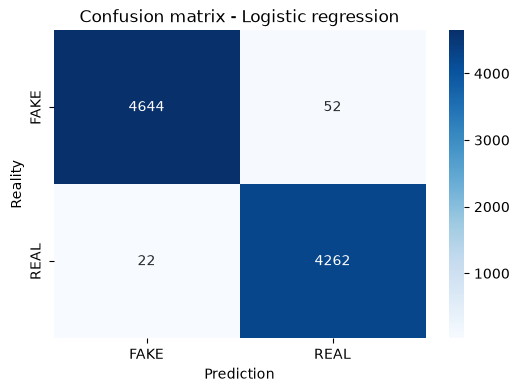

Logistic regression saved in 'models/'


In [4]:
# Logistic regression
print("LOGISTIC REGRESSION")

# Calculating class weights for balancing
class_weight = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weight[0], 1: class_weight[1]}
print(f"Class weight: {class_weight_dict}")

# Create the model
log_reg = LogisticRegression(
    C=1.0,
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42,
    solver='liblinear'
)

results['log_reg'] = train_and_evaluate(
    log_reg, "Logistic regression",
    X_train, X_test, y_train, y_test
)

# Save model
with open('models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(log_reg, f)
print("Logistic regression saved in 'models/'")


SVM
TRAIN: SVM (linear core)
Accuracy: 0.9967
Precision: 0.9953
Recall: 0.9977
F1 score: 0.9965
ROC-AUC: 0.9998
Learning time: 955.2069160938263

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      4696
        REAL       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



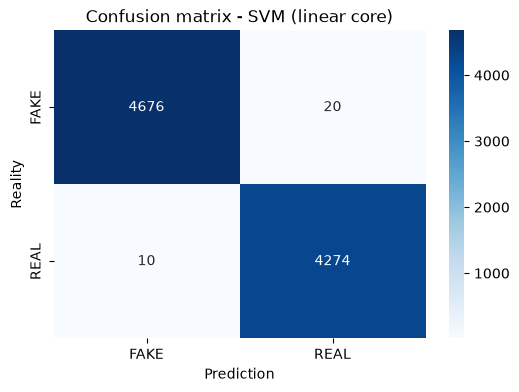

SVM saved in 'models/'


In [5]:
# SVM
print("SVM")

svm_model = SVC(
    C=1.0,
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

results['svm'] = train_and_evaluate(
    svm_model, 'SVM (linear core)',
    X_train, X_test, y_train, y_test
)

with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
    
print("SVM saved in 'models/'")


RANDOM FOREST
TRAIN: Random forest
Accuracy: 0.9923
Precision: 0.9871
Recall: 0.9970
F1 score: 0.9920
ROC-AUC: 0.9995
Learning time: 3.128462076187134

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      0.99      0.99      4696
        REAL       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



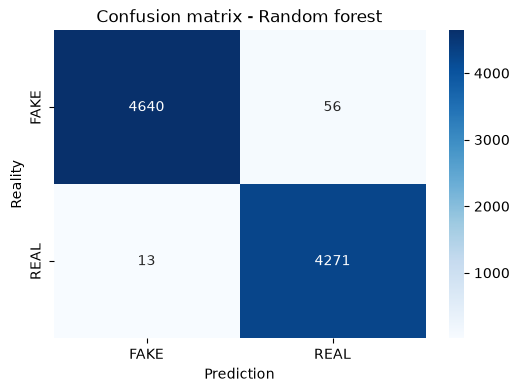

Random forest saved in 'models/'


In [6]:
# Random forest
print("RANDOM FOREST")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

results['rf'] = train_and_evaluate(
    rf_model, "Random forest",
    X_train, X_test, y_train, y_test
)

with open('models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("Random forest saved in 'models/'")


XGBoost
TRAIN: XGBoost
Accuracy: 0.9982
Precision: 0.9986
Recall: 0.9977
F1 score: 0.9981
ROC-AUC: 0.9999
Learning time: 56.91718864440918

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      4696
        REAL       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



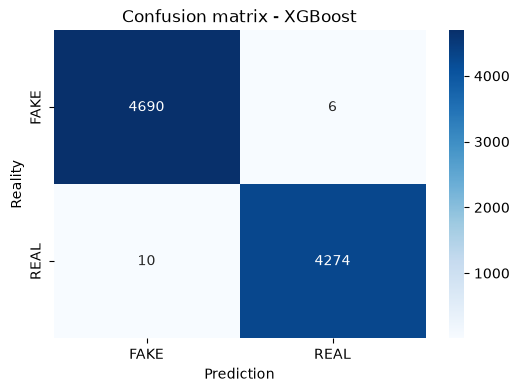

XGBoost saved in 'models/'


In [7]:
# XGBoost
print("XGBoost")

# XGBoost requires dense data
X_train_dense = X_train.toarray()
X_test_dendse = X_test.toarray()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=sum(y_train==0)/sum(y_train==1),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

results['xgb'] = train_and_evaluate(
    xgb_model, "XGBoost",
    X_train_dense, X_test_dendse, y_train, y_test
)

with open('models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("XGBoost saved in 'models/'")


In [13]:
# Create results table with comparison models
comparison_data = {
    'Model': [results[m]['name'] for m in results],
    'Accuracy': [results[m].get('accuracy', 0) for m in results],
    'Precision': [results[m].get('precision', 0) for m in results],
    'Recall': [results[m].get('recall', 0) for m in results],
    'F1-Score': [results[m].get('f1', 0) for m in results],
}

# Add ROC-AUC only if all models have it
roc_auc_values = []
for m in results:
    if 'roc_auc' in results[m] and results[m]['roc_auc'] is not None:
        roc_auc_values.append(results[m]['roc_auc'])
    else:
        roc_auc_values.append('N/A')  

comparison_data['ROC-AUC'] = roc_auc_values
comparison_data['Время (сек)'] = [results[m].get('training_time', 0) for m in results]

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Sorted F1-Score
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print("Comparison table:")
print(comparison_df.to_string(index=False))

# Save tables
comparison_df.to_csv('models/model_comparison.csv', index=False)
print("\nTable saved in 'models/'")

Comparison table:
              Model  Accuracy  Precision   Recall  F1-Score ROC-AUC  Время (сек)
            XGBoost  0.998218   0.998598 0.997666  0.998132     N/A    56.917189
  SVM (linear core)  0.996659   0.995342 0.997666  0.996503     N/A   955.206916
      Random forest  0.992316   0.987058 0.996965  0.991987     N/A     3.128462
Logistic regression  0.991759   0.987946 0.994865  0.991393     N/A     0.908349

Table saved in 'models/'


In [18]:
# Find the best model by F1-Score
# Get the model name from the first row (highest F1-Score)
best_model_name = comparison_df.iloc[0]['Model']  # Use 'Модель' column name
best_model = None

# Search for the model in the results dictionary
for key, value in results.items():  # Use .items() to iterate over dictionary
    if value['name'] == best_model_name:
        best_model = value['model']
        break
    
if best_model:
    # Save the trained model to disk
    with open('models/best_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print(f"Best model saved: {best_model_name}")
    print(f"F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")  # Use single quotes inside f-string
    print(f"Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")   # Use single quotes inside f-string
    
    # Save metadata about the best model
    best_model_info = {
        'name': best_model_name,
        'accuracy': comparison_df.iloc[0]['Accuracy'],
        'precision': comparison_df.iloc[0]['Precision'],
        'recall': comparison_df.iloc[0]['Recall'],
        'f1_score': comparison_df.iloc[0]['F1-Score'],
        'roc_auc': comparison_df.iloc[0]['ROC-AUC'],
        'training_time': comparison_df.iloc[0]['Время (сек)']
    }
    
    # Save metadata to disk
    with open('models/best_model_info.pkl', 'wb') as f:
        pickle.dump(best_model_info, f)
    print("Best model metadata saved")
else:
    print("Could not find the best model")

Best model saved: XGBoost
F1-Score: 0.9981
Accuracy: 0.9982
Best model metadata saved
